In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

248:
	Xi = 0.24824824824824823 pi
	Px:17.686160704656622 Py:5.895386901552207


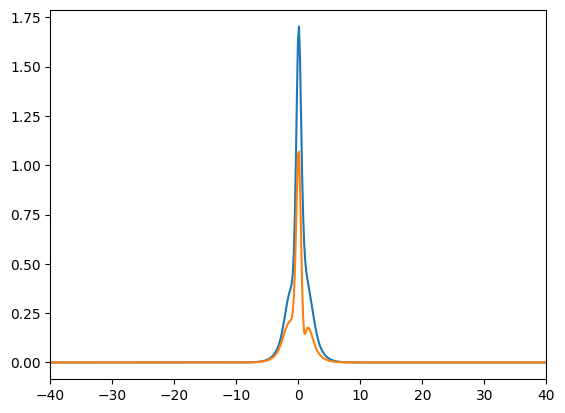

498:
	Xi = 0.4984984984984985 pi
	Px:17.6861607046591 Py:5.895386901553045


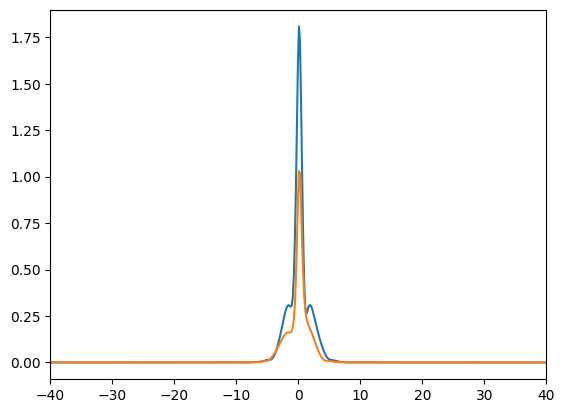

748:
	Xi = 0.7487487487487486 pi
	Px:17.686160704661763 Py:5.895386901553886


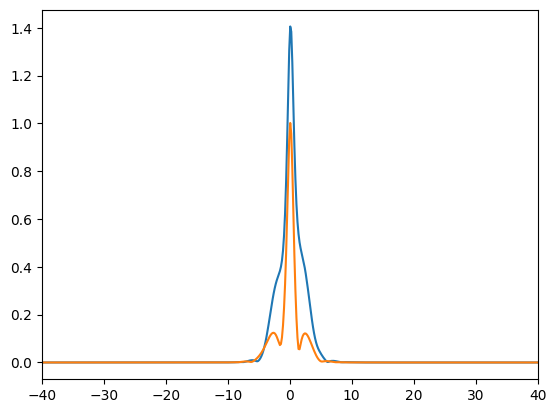

998:
	Xi = 0.9989989989989989 pi
	Px:17.686160704664406 Py:5.895386901554722


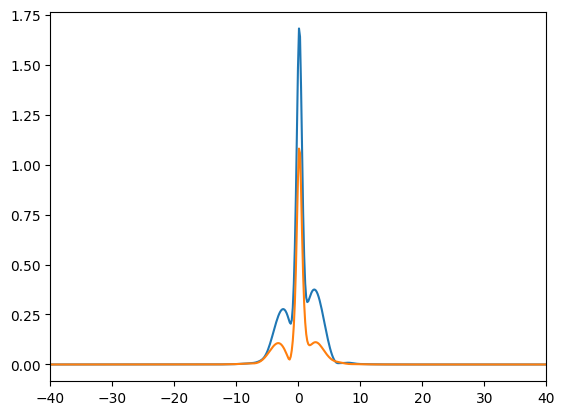

In [167]:
import NLSE

theta = np.pi / 6

tau = np.linspace(-100, 100, 1200)
Xi = np.linspace(0, np.pi, 1000)

N = 1.4024150385914693 + 0j

LCP_0 = N * np.cos(theta) / np.cosh(tau)
RCP_0 = N * np.sin(theta) / np.cosh(tau)

A = NLSE.split_step_2d_unitless(np.vstack((LCP_0, RCP_0)), tau, Xi, delta=0.15, n_integral_iterations=3)
LCP = A[:,0]
RCP = A[:,1]

A_X = LCP + RCP / np.sqrt(2)
A_Y = -1j * ( LCP - RCP ) / np.sqrt(2)

for i in range(4):
    ind = ( Xi.size // 4 ) * ( i + 1 ) - 2
    print(f'{ind}:\n\tXi = {Xi[ind] / np.pi} pi')
    print(f'\tPx:{np.trapezoid(np.abs(LCP[ind])**2)} Py:{np.trapezoid(np.abs(RCP[ind])**2)}')

    plt.plot(tau, np.abs(LCP[ind]))
    plt.plot(tau, np.abs(RCP[ind]))
    plt.xlim(-40,40)
    plt.show()

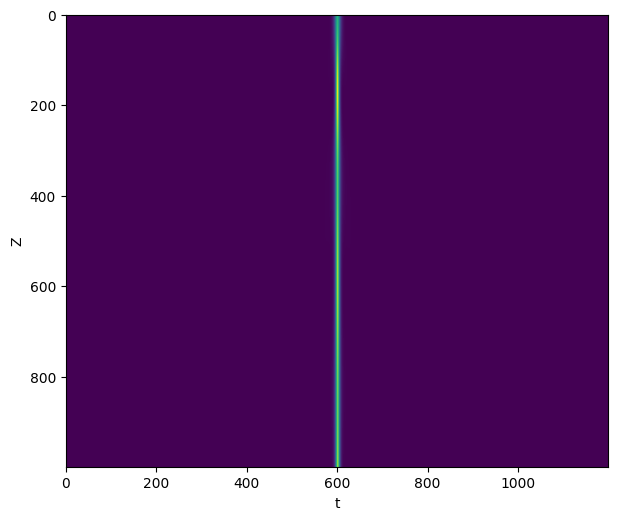

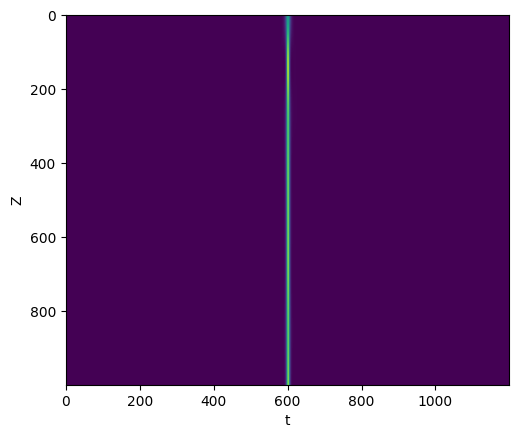

In [141]:
mid = tau[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(LCP)**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

plt.imshow(np.abs(RCP)**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

# plt.imshow(np.abs(RCP / LCP)**2)
# plt.ylabel('Z')
# plt.xlabel('t')
# plt.show()

In [168]:
from matplotlib import animation
from matplotlib import patches
from copy import copy

fig, ax = plt.subplots(1, 2, figsize=(10,5))

fig.suptitle('Polarization at fiber output')

start_ind = min(np.argwhere(tau > (-10)).flatten())
end_ind = min(np.argwhere(tau > (10)).flatten())

ax[0].plot(tau[start_ind:end_ind], np.abs(LCP[-1, start_ind:end_ind]), 'b', label='LCP')
ax[0].plot(tau[start_ind:end_ind], np.abs(RCP[-1, start_ind:end_ind]), 'r:', label='RCP')

ax[0].legend()

ax[1].set_xlim(-1,1)
ax[1].set_ylim(-1,1)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_aspect('equal')

def animate(ind):
    if ax[1].has_data():
        [ patch.remove() for patch in ax[1].patches ]

    alpha =  RCP[-1, ind] / LCP[-1, ind]
    phi = np.angle( alpha ) * 360 / ( 2 * np.pi )
    ellipse = patches.Ellipse((0,0), 1, np.abs(alpha), angle=phi, color='red', fill=False)

    patch = ax[1].add_patch(ellipse)

    if len(ax[0].lines) > 2:
        ax[0].lines[-1].remove()
        
    ax[0].axvline(tau[ind], color='g', lw=0.5)
    return [ patch ]
    
ani = animation.FuncAnimation(fig, animate, frames=range(start_ind, end_ind + 1), interval=1000/24)

plt.close()

from IPython.display import HTML
# ani.save('images/polarization.gif')
HTML(ani.to_jshtml())